**Análise de série**

Text(0, 0.5, 'Unidade de medição de vento')

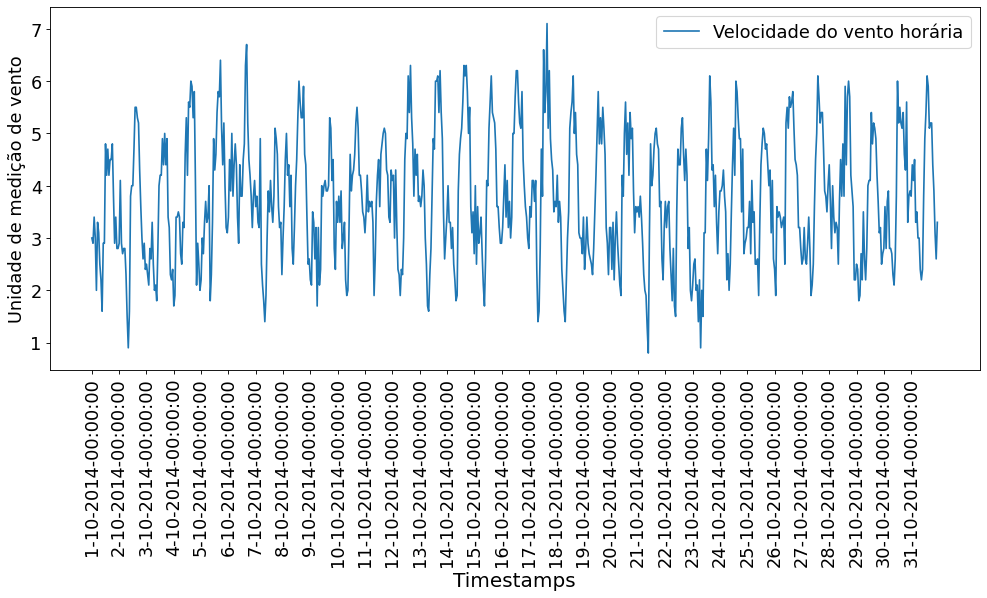

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sbn

data_horario = pd.read_excel('BASEFORTALEZAhorario.xlsx')

plt.figure(figsize=(15, 6),dpi=80)
data_horario['Data'] = pd.DatetimeIndex(data_horario['DATA (YYYY-MM-DD)']).day.map(str)+'-'+ pd.DatetimeIndex(data_horario['DATA (YYYY-MM-DD)']).month.map(str)+'-' + pd.DatetimeIndex(data_horario['DATA (YYYY-MM-DD)']).year.map(str)+'-'+data_horario['HORA (UTC)'].map(str)
plt.plot(data_horario.iloc[:,-1],data_horario.iloc[:,4])
plt.legend(['Velocidade do vento horária'],fontsize=16)
plt.xlabel('Timestamps',fontsize=18)
plt.xticks(rotation=90)
plt.xticks(np.arange(0, len(data_horario), 24),fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel('Unidade de medição de vento',fontsize=16)



Text(0, 0.5, 'Unidade de medição de Precipitação')

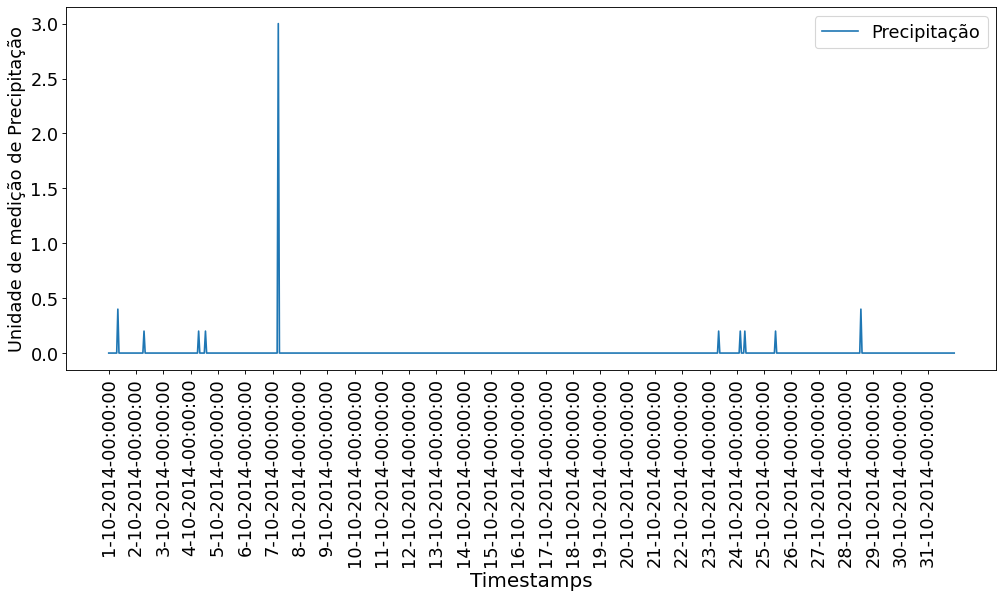

In [ ]:
plt.figure(figsize=(15, 6),dpi=80)
plt.plot(data_horario.iloc[:,-1],data_horario.iloc[:,2])
plt.legend(['Precipitação'],fontsize=16)
plt.xlabel('Timestamps',fontsize=18)
plt.xticks(rotation=90)
plt.xticks(np.arange(0, len(data_horario), 24),fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel('Unidade de medição de Precipitação',fontsize=16)

Text(0, 0.5, 'Unidade de medição de Temperatura')

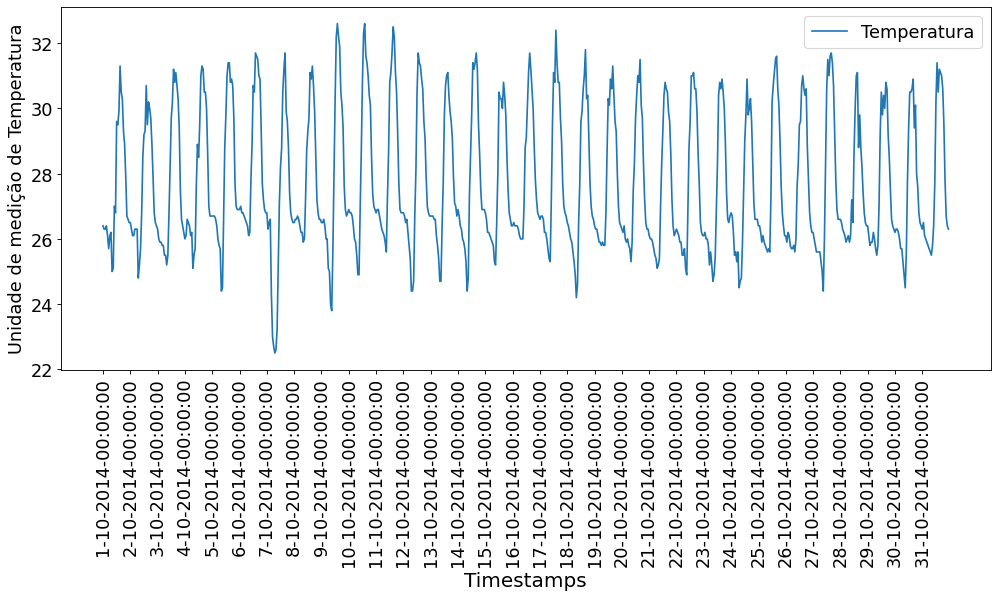

In [ ]:
plt.figure(figsize=(15, 6),dpi=80)
plt.plot(data_horario.iloc[:,-1],data_horario.iloc[:,3])
plt.legend(['Temperatura'],fontsize=16)
plt.xlabel('Timestamps',fontsize=18)
plt.xticks(rotation=90)
plt.xticks(np.arange(0, len(data_horario), 24),fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel('Unidade de medição de Temperatura',fontsize=16)

Text(0, 0.5, 'Unidade de medição de Pressão')

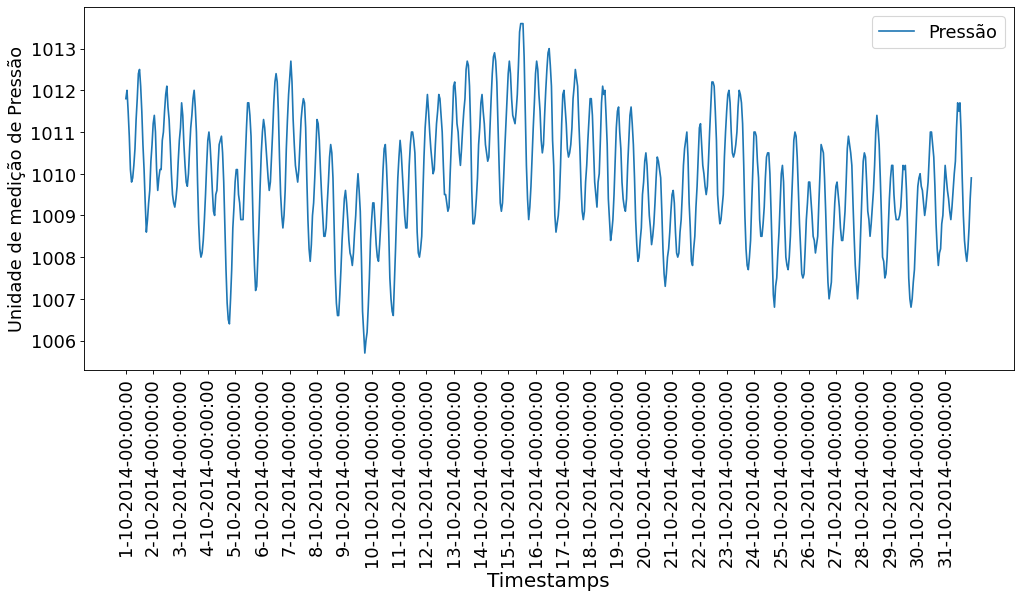

In [ ]:

plt.figure(figsize=(15, 6),dpi=80)
plt.plot(data_horario.iloc[:,-1],data_horario.iloc[:,5])
plt.legend(['Pressão'],fontsize=16)
plt.xlabel('Timestamps',fontsize=18)
plt.xticks(rotation=90)
plt.xticks(np.arange(0, len(data_horario), 24),fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel('Unidade de medição de Pressão',fontsize=16)

**Análise de correlação entre séries**

,PRECIPITACAO,TEMPERATURA,VELOCIDADE,PRESSAO
PRECIPITACAO,1.000000,-0.094962,-0.055610,0.015477
TEMPERATURA,-0.094962,1.000000,0.814527,-0.088524
VELOCIDADE,-0.055610,0.814527,1.000000,-0.072784
PRESSAO,0.015477,-0.088524,-0.072784,1.000000


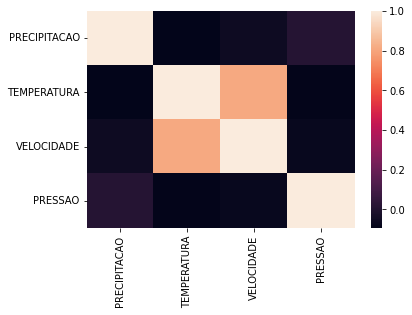

In [ ]:
sbn.heatmap(data_horario.corr())
data_horario.corr()

**Decomposição de séries**

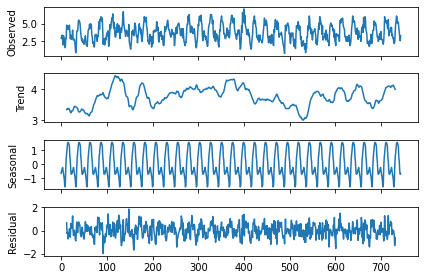

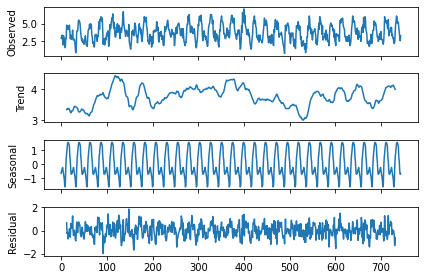

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose_result = seasonal_decompose(data_horario.iloc[:,4],model="additive",freq=24)

decompose_result.plot()


**Análise de Distribuição**


{datetime.time(0, 0): 0      3.0
24     2.9
48     2.5
72     1.7
96     2.2
120    3.4
144    3.6
168    3.0
192    2.2
216    3.3
240    3.1
264    4.1
288    3.8
312    3.4
336    2.7
360    2.9
384    2.8
408    3.6
432    3.4
456    3.2
480    3.6
504    3.7
528    2.1
552    3.9
576    3.2
600    2.4
624    2.5
648    4.4
672    2.5
696    2.8
720    3.8
Name: VELOCIDADE, dtype: float64, datetime.time(1, 0): 1      2.9
25     4.1
49     2.3
73     1.9
97     3.0
121    4.5
145    3.8
169    3.6
193    2.1
217    3.8
241    3.5
265    4.2
289    3.6
313    4.0
337    4.0
361    3.2
385    3.6
409    4.2
433    2.4
457    2.4
481    3.4
505    3.2
529    2.5
553    3.9
577    3.2
601    1.9
625    2.6
649    3.7
673    2.4
697    3.6
721    4.4
Name: VELOCIDADE, dtype: float64, datetime.time(2, 0): 2      3.4
26     2.9
50     2.1
74     3.4
98     2.7
122    3.9
146    3.3
170    4.5
194    3.5
218    3.3
242    4.2
266    3.0
290    3.8
314    3.3
338    2.5
362    3.8
386    3.4

Text(0, 0.5, 'Unidades de Velocidade do vento')

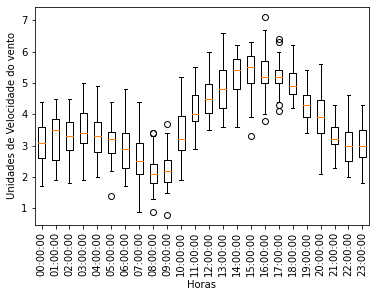

In [ ]:
data_horario.iloc[:,1]
hours = np.sort(list(set(data_horario.iloc[:,1])))
speeds=[]
for i in range((24)):
  speeds.append(data_horario[data_horario['HORA (UTC)']==hours[i]].iloc[:,4])
my_dc = {}
for i in range(24):
  my_dc[hours[i]]=speeds[i]

fig, ax = plt.subplots()
ax.boxplot(my_dc.values())
ax.set_xticklabels(my_dc.keys(),rotation=90)
ax.set_xlabel('Horas')
ax.set_ylabel('Unidades de Velocidade do vento')





**Exercício: Fazer a análise da base 'BASEFORTALEZAmensal.xlsx'**

**Parte 2: Análise de Autocorrelação**

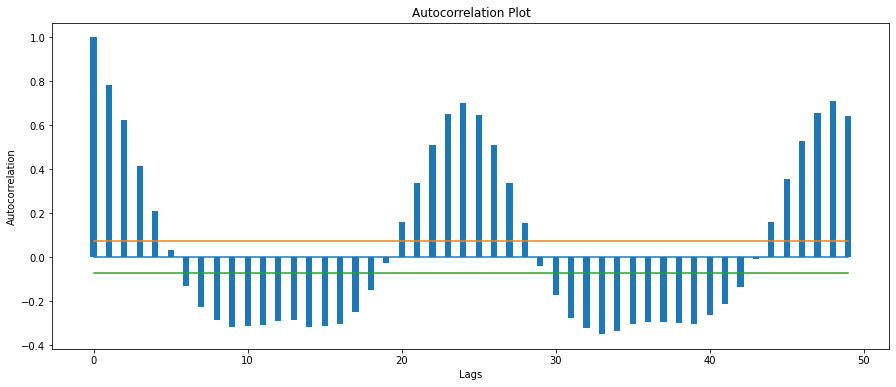

In [ ]:
def acf_plot(data,lags):
    values=[]
    for i in range((lags)):
        values.append(data.autocorr(i))
    plt.figure(figsize=(15,6))
    plt.plot(np.zeros_like(values))
    plt.plot(np.ones_like(values)*1.96*(1/np.sqrt(len(data))))
    plt.plot(np.ones_like(values)*(-1.96)*(1/np.sqrt(len(data))))
    plt.bar(range(lags),values,width=0.4)
    plt.title('Autocorrelation Plot')
    plt.xlabel('Lags')
    plt.ylabel('Autocorrelation')
    plt.show()

acf_plot(data_horario.iloc[:,4],50)

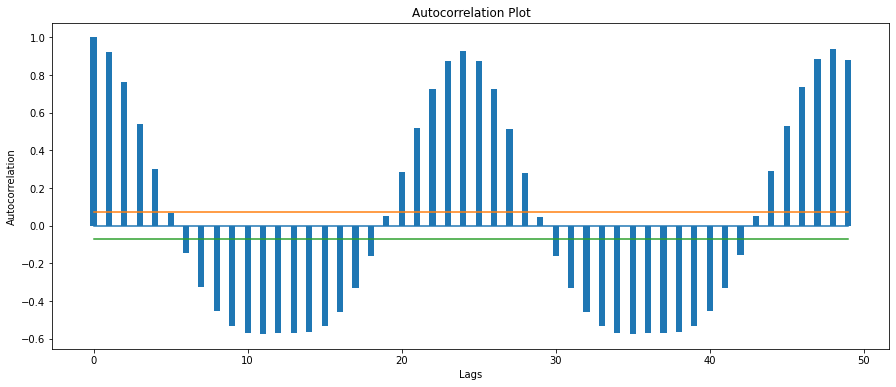

In [ ]:
acf_plot(data_horario.iloc[:,3],50)

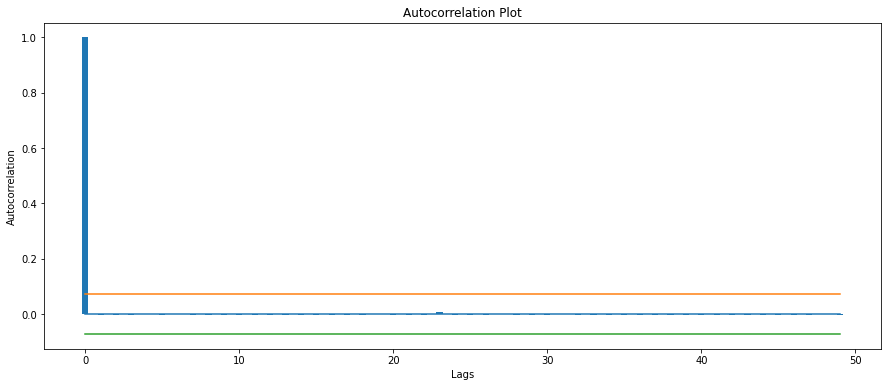

In [ ]:
acf_plot(data_horario.iloc[:,2],50)

**É possível prever os números da mega-sena?**

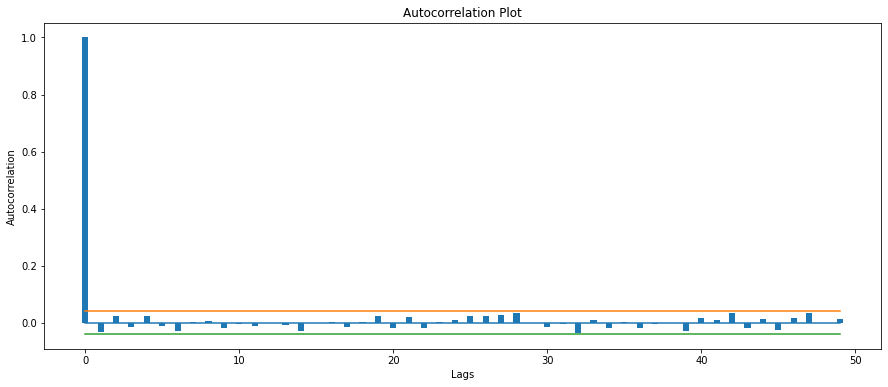

In [ ]:
import pandas as pd
data_ms= pd.read_excel('megasena.xlsx')
data_ms_inv = data_ms.iloc[::-1,:]
data_ms_inv
acf_plot(data_ms_inv.iloc[:,2],50)


Testes estatísticos para estacionariedade: **Augmented Dickey-Fuller**
Exemplo com a Temperatura

In [ ]:
from statsmodels.tsa.stattools import adfuller

res=adfuller(data_horario.iloc[:,3])
print('ADF Statistic: %f' % res[0])
print('p-value: %f' % res[1])
print('Critical Values:')
for key, value in res[4].items():
	print('\t%s: %.3f' % (key, value))

ADF Statistic: -4.845592
p-value: 0.000044
Critical Values:
	1%: -3.439
	5%: -2.866
	10%: -2.569


Testes estatísticos para estacionariedade: Augmented Dickey-Fuller Exemplo com a Velocidade do vento

In [ ]:
res=adfuller(data_horario.iloc[:,4])
print('ADF Statistic: %f' % res[0])
print('p-value: %f' % res[1])
print('Critical Values:')
for key, value in res[4].items():
	print('\t%s: %.3f' % (key, value))

ADF Statistic: -5.042920
p-value: 0.000018
Critical Values:
	1%: -3.439
	5%: -2.866
	10%: -2.569


Testes estatísticos para estacionariedade: Augmented Dickey-Fuller Exemplo com a série PM2.5

ADF Statistic: -1.733543
p-value: 0.413918
Critical Values:
	1%: -3.488
	5%: -2.887
	10%: -2.580


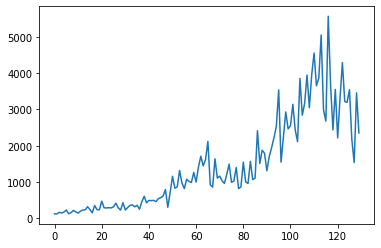

In [ ]:
data_pollution = np.loadtxt('pollutn.txt')
plt.plot(range(len(data_pollution)),data_pollution)
res=adfuller(data_pollution)
print('ADF Statistic: %f' % res[0])
print('p-value: %f' % res[1])
print('Critical Values:')
for key, value in res[4].items():
	print('\t%s: %.3f' % (key, value))
